In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
import seaborn as sns

# Affichage plus propre
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [3]:
freq = pd.read_csv("../data/raw/freMTPL2freq.csv")
sev = pd.read_csv("../data/raw/freMTPL2sev.csv")

In [4]:
print("Fréquence :", freq.shape)
print("Sévérité :", sev.shape)

Fréquence : (678013, 12)
Sévérité : (26639, 2)


In [5]:
freq.info()

<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   VehPower    678013 non-null  int64  
 4   VehAge      678013 non-null  int64  
 5   DrivAge     678013 non-null  int64  
 6   BonusMalus  678013 non-null  int64  
 7   VehBrand    678013 non-null  str    
 8   VehGas      678013 non-null  str    
 9   Area        678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 62.1 MB


In [6]:
sev.info()

<class 'pandas.DataFrame'>
RangeIndex: 26639 entries, 0 to 26638
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        26639 non-null  int64  
 1   ClaimAmount  26639 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 416.4 KB


In [7]:
freq.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine


In [8]:
sev.head()

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00


In [9]:
print(freq.columns)

Index(['IDpol', 'ClaimNb', 'Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region'], dtype='str')


In [10]:
print(sev.columns)

Index(['IDpol', 'ClaimAmount'], dtype='str')


In [11]:
freq.isnull().sum()

IDpol         0
ClaimNb       0
Exposure      0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Area          0
Density       0
Region        0
dtype: int64

In [12]:
sev.isnull().sum()

IDpol          0
ClaimAmount    0
dtype: int64

In [13]:
freq.describe()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
count,6.780130e+05,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000,678013.000000
mean,2.621857e+06,0.053247,0.528750,6.454631,7.044265,45.499122,59.761502,1792.422405
std,1.641783e+06,0.240117,0.364442,2.050906,5.666232,14.137444,15.636658,3958.646564
min,1.000000e+00,0.000000,0.002732,4.000000,0.000000,18.000000,50.000000,1.000000
25%,1.157951e+06,0.000000,0.180000,5.000000,2.000000,34.000000,50.000000,92.000000
50%,2.272152e+06,0.000000,0.490000,6.000000,6.000000,44.000000,50.000000,393.000000
75%,4.046274e+06,0.000000,0.990000,7.000000,11.000000,55.000000,64.000000,1658.000000
max,6.114330e+06,16.000000,2.010000,15.000000,100.000000,100.000000,230.000000,27000.000000


In [14]:
sev.describe()

,IDpol,ClaimAmount
count,2.663900e+04,2.663900e+04
mean,2.279864e+06,2.278536e+03
std,1.577202e+06,2.929748e+04
min,1.390000e+02,1.000000e+00
25%,1.087642e+06,6.868100e+02
50%,2.137413e+06,1.172000e+03
75%,3.180162e+06,1.228080e+03
max,6.113971e+06,4.075401e+06


In [15]:
freq["ClaimNb"].value_counts().sort_index()

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

In [16]:
freq["ClaimNb"].value_counts(normalize=True).sort_index() * 100

ClaimNb
0     94.976498
1      4.745927
2      0.263122
3      0.012094
4      0.001032
5      0.000295
6      0.000147
8      0.000147
9      0.000147
11     0.000442
16     0.000147
Name: proportion, dtype: float64

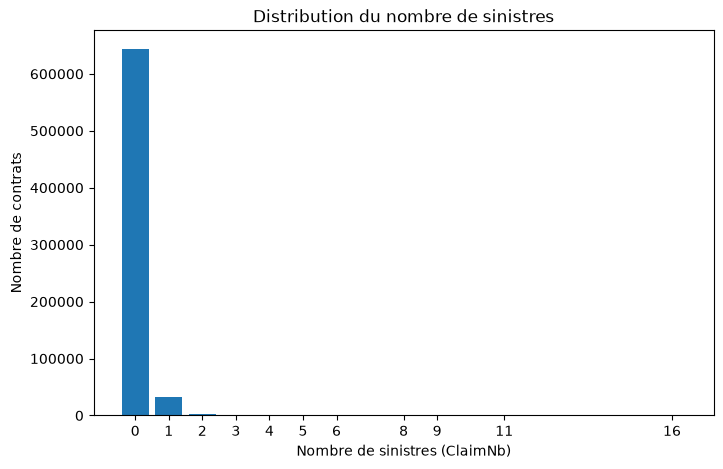

In [17]:

import matplotlib.pyplot as plt

claim_counts = freq["ClaimNb"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(claim_counts.index, claim_counts.values)
plt.title("Distribution du nombre de sinistres")
plt.xlabel("Nombre de sinistres (ClaimNb)")
plt.ylabel("Nombre de contrats")
plt.xticks(claim_counts.index)
plt.show()

In [18]:

freq["HasClaim"] = (freq["ClaimNb"] > 0).astype(int)

freq["HasClaim"].value_counts()

HasClaim
0    643953
1     34060
Name: count, dtype: int64

La colonne HasClaim n'existe pas dans le dataset d'origine. Elle a été créée à partir de la variable ClaimNb afin de transformer le problème en une classification binaire. Un contrat est considéré comme sinistré (HasClaim = 1) si ClaimNb > 0, sinon HasClaim = 0. Cette variable sera utilisée comme variable cible pour prédire la probabilité qu'un assuré ait au moins un sinistre.

In [26]:

distribution = pd.DataFrame({
    "Nombre de contrats": freq["HasClaim"].value_counts(),
    "Pourcentage (%)": (freq["HasClaim"].value_counts(normalize=True) * 100).round(2)
})

distribution

,Nombre de contrats,Pourcentage (%)
HasClaim,,
0,643953,94.98
1,34060,5.02


Interprétation

La fonction value_counts(normalize=True) permet de calculer la proportion de chaque catégorie de la variable HasClaim. Après multiplication par 100, les résultats sont exprimés en pourcentage.

L'analyse montre que 94,98 % des contrats n'ont déclaré aucun sinistre (HasClaim = 0), tandis que 5,02 % ont déclaré au moins un sinistre (HasClaim = 1).

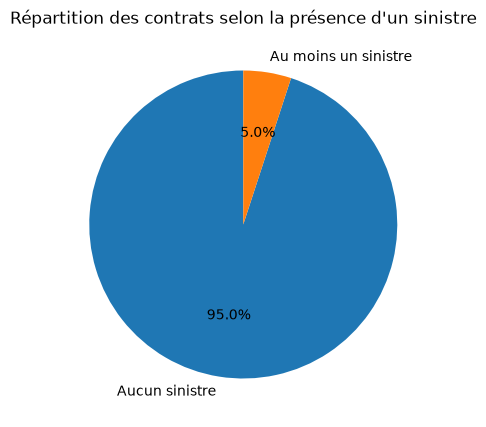

In [20]:

risk = freq["HasClaim"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    risk.values,
    labels=["Aucun sinistre", "Au moins un sinistre"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des contrats selon la présence d'un sinistre")
plt.show()

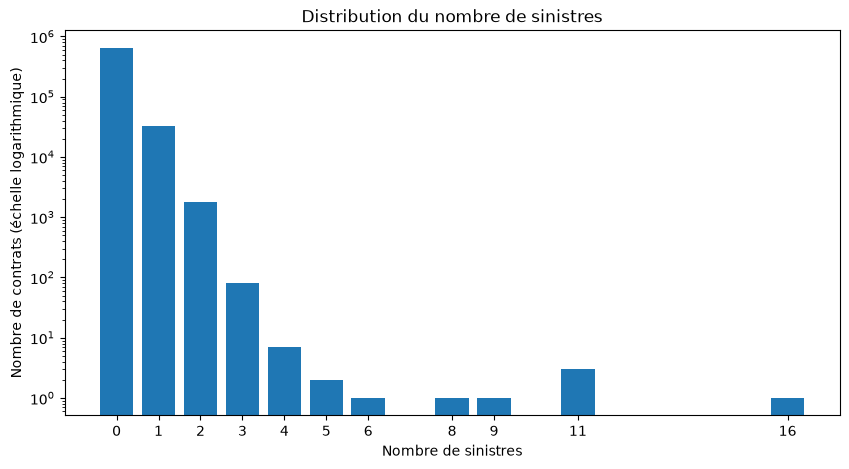

In [21]:
claim_counts = freq["ClaimNb"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(claim_counts.index, claim_counts.values)

plt.yscale("log")

plt.title("Distribution du nombre de sinistres")
plt.xlabel("Nombre de sinistres")
plt.ylabel("Nombre de contrats (échelle logarithmique)")

plt.xticks(claim_counts.index)

plt.show()

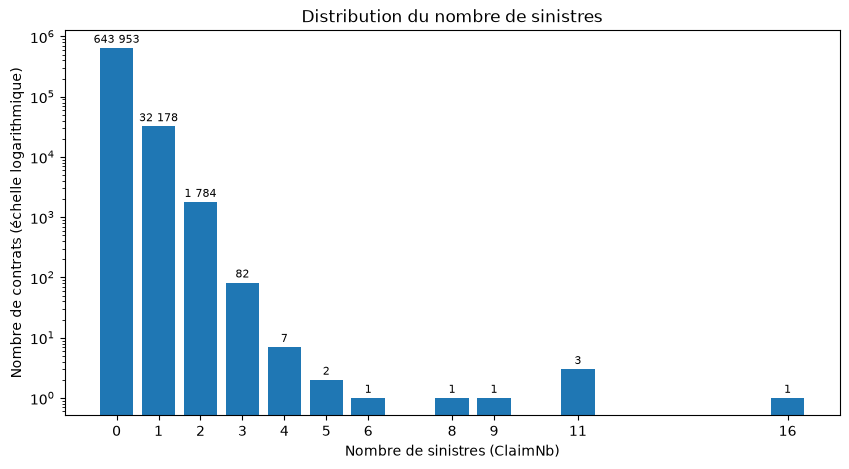

In [22]:
claim_counts = freq["ClaimNb"].value_counts().sort_index()

plt.figure(figsize=(10,5))

bars = plt.bar(claim_counts.index, claim_counts.values)

plt.yscale("log")

plt.title("Distribution du nombre de sinistres")
plt.xlabel("Nombre de sinistres (ClaimNb)")
plt.ylabel("Nombre de contrats (échelle logarithmique)")
plt.xticks(claim_counts.index)

# Afficher les valeurs exactes sur les barres
for bar, value in zip(bars, claim_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value * 1.1,          # un peu au-dessus de la barre
        f"{value:,}".replace(",", " "),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.show()

In [23]:
# Création des groupes d'âge

bins = [18, 25, 35, 50, 100]
labels = ["18-25", "26-35", "36-50", "51+"]

freq["AgeGroup"] = pd.cut(
    freq["DrivAge"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [28]:
risk_by_age = (
    freq.groupby("AgeGroup")["HasClaim"]
    .mean()
    .mul(100)
    .round(2)
)

age_analysis = pd.DataFrame({
    "Nombre de conducteurs": freq["AgeGroup"].value_counts().sort_index(),
    "Fréquence des sinistres (%)": risk_by_age
})

age_analysis

,Nombre de conducteurs,Fréquence des sinistres (%)
AgeGroup,,
18-25,38895,6.74
26-35,149183,4.23
36-50,251693,4.95
51+,238242,5.32


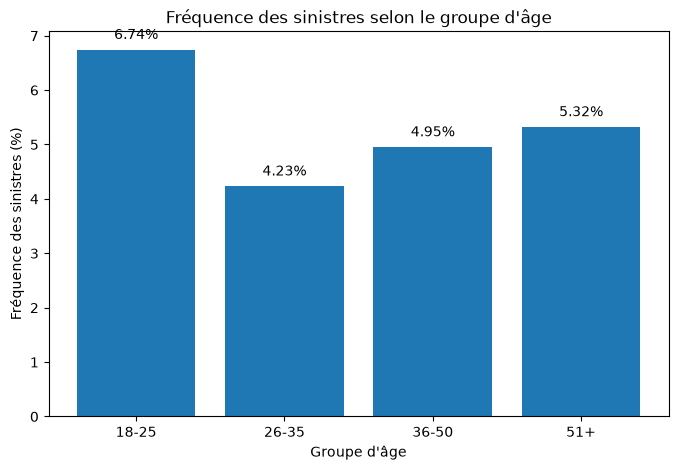

In [25]:
plt.figure(figsize=(8,5))

bars = plt.bar(risk_by_age.index.astype(str), risk_by_age.values)

plt.title("Fréquence des sinistres selon le groupe d'âge")
plt.xlabel("Groupe d'âge")
plt.ylabel("Fréquence des sinistres (%)")

# Afficher les pourcentages sur les barres
for bar, value in zip(bars, risk_by_age.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

In [29]:
# Création des groupes Bonus-Malus

bm_bins = [50, 75, 100, 150, 230]
bm_labels = ["50-75", "76-100", "101-150", "151-230"]

freq["BonusGroup"] = pd.cut(
    freq["BonusMalus"],
    bins=bm_bins,
    labels=bm_labels,
    include_lowest=True
)

In [30]:
risk_by_bonus = (
    freq.groupby("BonusGroup")["HasClaim"]
    .mean()
    .mul(100)
    .round(2)
)

In [31]:
bonus_analysis = pd.DataFrame({
    "Nombre de conducteurs": freq["BonusGroup"].value_counts().sort_index(),
    "Fréquence des sinistres (%)": risk_by_bonus
})

bonus_analysis

,Nombre de conducteurs,Fréquence des sinistres (%)
BonusGroup,,
50-75,559168,4.69
76-100,111051,5.95
101-150,7585,15.46
151-230,209,19.14


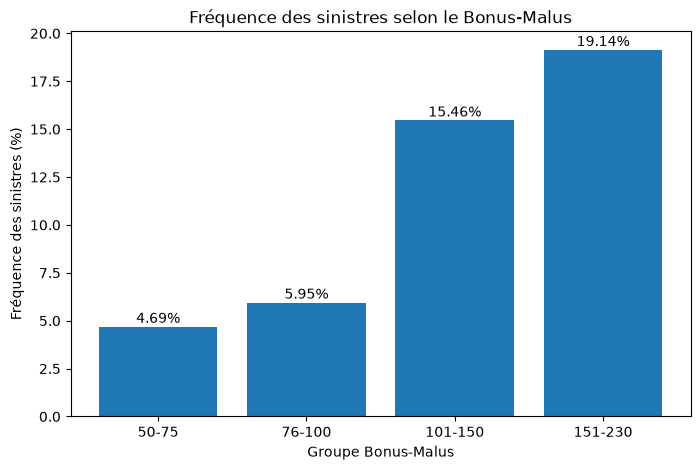

In [32]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    bonus_analysis.index.astype(str),
    bonus_analysis["Fréquence des sinistres (%)"]
)

plt.title("Fréquence des sinistres selon le Bonus-Malus")
plt.xlabel("Groupe Bonus-Malus")
plt.ylabel("Fréquence des sinistres (%)")

for bar, value in zip(bars, bonus_analysis["Fréquence des sinistres (%)"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

### Interprétation

Cette analyse compare la fréquence des sinistres selon les groupes de Bonus-Malus.

L'objectif est de vérifier si un coefficient Bonus-Malus plus élevé est associé à un niveau de risque plus important.

Les résultats permettront de déterminer si cette variable constitue un facteur explicatif pertinent pour le modèle de prédiction.

In [34]:
freq["VehAge"].describe()

count    678013.000000
mean          7.044265
std           5.666232
min           0.000000
25%           2.000000
50%           6.000000
75%          11.000000
max         100.000000
Name: VehAge, dtype: float64

Interprétation

L'âge moyen des véhicules est de 7,04 ans, tandis que la médiane est de 6 ans. Cela indique que la majorité des véhicules sont relativement récents. Le troisième quartile est de 11 ans, ce qui signifie que 75 % des véhicules ont 11 ans ou moins. La valeur maximale de 100 ans constitue une valeur extrême qui sera prise en compte lors de l'interprétation des résultats.

In [35]:
veh_bins = [0, 2, 5, 10, 100]
veh_labels = ["0-2", "3-5", "6-10", "11+"]

freq["VehAgeGroup"] = pd.cut(
    freq["VehAge"],
    bins=veh_bins,
    labels=veh_labels,
    include_lowest=True
)

In [36]:
risk_by_vehicle_age = (
    freq.groupby("VehAgeGroup")["HasClaim"]
    .mean()
    .mul(100)
    .round(2)
)

vehicle_analysis = pd.DataFrame({
    "Nombre de véhicules": freq["VehAgeGroup"].value_counts().sort_index(),
    "Fréquence des sinistres (%)": risk_by_vehicle_age
})

vehicle_analysis

,Nombre de véhicules,Fréquence des sinistres (%)
VehAgeGroup,,
0-2,188147,5.45
3-5,132490,4.79
6-10,171594,5.42
11+,185782,4.39


Cette analyse compare la fréquence des sinistres selon quatre groupes d'âge du véhicule.

Les véhicules de 0 à 2 ans présentent une fréquence de sinistre de 5,45 %, tandis que ceux de 6 à 10 ans atteignent 5,42 %. En revanche, les véhicules de 11 ans et plus affichent une fréquence plus faible (4,39 %).

Les résultats ne montrent donc pas une augmentation régulière du risque avec l'âge du véhicule. L'ancienneté du véhicule ne semble pas, à elle seule, expliquer la fréquence des sinistres dans ce portefeuille.

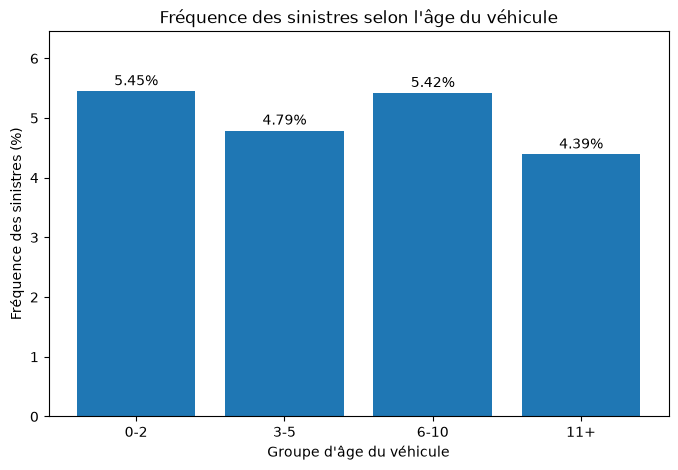

In [37]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    vehicle_analysis.index.astype(str),
    vehicle_analysis["Fréquence des sinistres (%)"]
)

plt.title("Fréquence des sinistres selon l'âge du véhicule")
plt.xlabel("Groupe d'âge du véhicule")
plt.ylabel("Fréquence des sinistres (%)")

# Afficher les pourcentages au-dessus des barres
for bar, value in zip(bars, vehicle_analysis["Fréquence des sinistres (%)"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.1,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.ylim(0, max(vehicle_analysis["Fréquence des sinistres (%)"]) + 1)

plt.show()

Les véhicules de 0 à 2 ans présentent une fréquence de sinistre de 5,45 %, tandis que les véhicules de 6 à 10 ans affichent une fréquence similaire (5,42 %). En revanche, les véhicules de 11 ans et plus présentent une fréquence plus faible (4,39 %).

Les résultats ne montrent donc pas une augmentation régulière du risque avec l'âge du véhicule. L'ancienneté du véhicule ne semble pas, à elle seule, expliquer la fréquence des sinistres dans ce portefeuille d'assurance

Analyse 5 — La puissance du véhicule influence-t-elle le risque ?

Cette analyse vise à déterminer si la puissance du véhicule est associée à une fréquence plus élevée de sinistres.

In [38]:
freq["VehPower"].describe()

count    678013.000000
mean          6.454631
std           2.050906
min           4.000000
25%           5.000000
50%           6.000000
75%           7.000000
max          15.000000
Name: VehPower, dtype: float64

In [39]:
freq["VehPower"].value_counts().sort_index()

VehPower
4     115349
5     124821
6     148976
7     145401
8      46956
9      30085
10     31354
11     18352
12      8214
13      3229
14      2350
15      2926
Name: count, dtype: int64

Interprétation

La majorité des véhicules possède une puissance comprise entre 4 et 7, qui représente la plus grande partie du portefeuille d'assurance. À partir de la puissance 8, le nombre de véhicules diminue progressivement, tandis que les puissances 13 à 15 sont relativement rares. Les groupes de puissance seront donc définis de manière à conserver un nombre suffisant d'observations dans chaque catégorie.

In [40]:
power_bins = [4, 5, 7, 10, 15]
power_labels = ["4-5", "6-7", "8-10", "11-15"]

freq["PowerGroup"] = pd.cut(
    freq["VehPower"],
    bins=power_bins,
    labels=power_labels,
    include_lowest=True
)

In [41]:
risk_by_power = (
    freq.groupby("PowerGroup")["HasClaim"]
    .mean()
    .mul(100)
    .round(2)
)

In [42]:
power_analysis = pd.DataFrame({
    "Nombre de véhicules": freq["PowerGroup"].value_counts().sort_index(),
    "Fréquence des sinistres (%)": risk_by_power
})

power_analysis

,Nombre de véhicules,Fréquence des sinistres (%)
PowerGroup,,
4-5,240170,5.08
6-7,294377,5.15
8-10,108395,4.76
11-15,35071,4.44


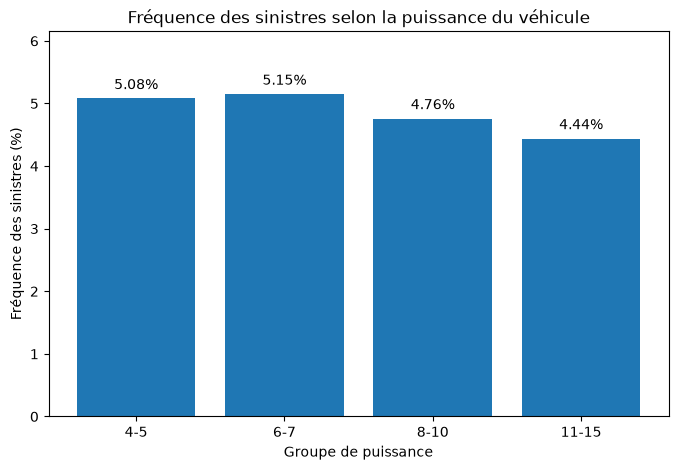

In [43]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    power_analysis.index.astype(str),
    power_analysis["Fréquence des sinistres (%)"]
)

plt.title("Fréquence des sinistres selon la puissance du véhicule")
plt.xlabel("Groupe de puissance")
plt.ylabel("Fréquence des sinistres (%)")

for bar, value in zip(bars, power_analysis["Fréquence des sinistres (%)"]):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        value+0.15,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.ylim(0, max(power_analysis["Fréquence des sinistres (%)"]) + 1)

plt.show()

In [44]:
freq["VehBrand"].value_counts()

VehBrand
B12    166024
B1     162736
B2     159861
B3      53395
B5      34753
B6      28548
B4      25179
B10     17707
B11     13585
B13     12178
B14      4047
Name: count, dtype: int64

In [45]:
risk_by_brand = (
    freq.groupby("VehBrand")["HasClaim"]
    .mean()
    .mul(100)
    .round(2)
)

In [46]:
brand_analysis = pd.DataFrame({
    "Nombre de véhicules": freq["VehBrand"].value_counts().sort_index(),
    "Fréquence des sinistres (%)": risk_by_brand
})

brand_analysis = brand_analysis.sort_values(
    by="Fréquence des sinistres (%)",
    ascending=False
)

brand_analysis

,Nombre de véhicules,Fréquence des sinistres (%)
VehBrand,,
B5,34753,5.51
B2,159861,5.08
B13,12178,5.03
B1,162736,5.02
B11,13585,5.01
B3,53395,5.00
B4,25179,4.98
B12,166024,4.97
B6,28548,4.86


Interprétation

Cette analyse compare la fréquence des sinistres selon les différentes marques de véhicules présentes dans le portefeuille.

Les résultats montrent que les fréquences observées varient entre 3,95 % (B14) et 5,51 % (B5). Les écarts restent relativement limités par rapport à ceux observés pour la variable BonusMalus.

Certaines marques, comme B14, sont représentées par un nombre plus faible de véhicules (4 047 contrats). Les différences observées doivent donc être interprétées avec prudence, car elles peuvent être influencées par la taille des groupes.

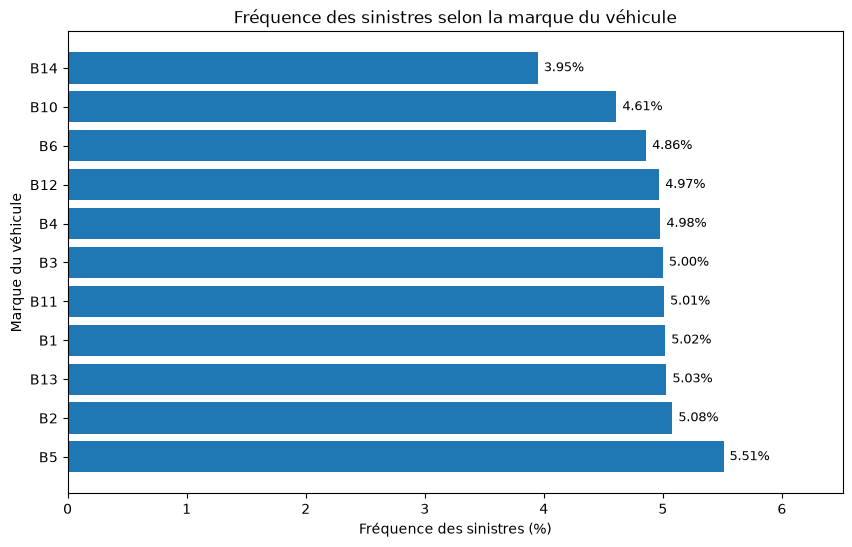

In [48]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    brand_analysis.index.astype(str),
    brand_analysis["Fréquence des sinistres (%)"]
)

plt.title("Fréquence des sinistres selon la marque du véhicule")
plt.xlabel("Fréquence des sinistres (%)")
plt.ylabel("Marque du véhicule")

# Afficher les pourcentages sur les barres
for bar, value in zip(bars, brand_analysis["Fréquence des sinistres (%)"]):
    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}%",
        va="center",
        fontsize=9
    )

# Laisser un peu d'espace à droite
plt.xlim(0, brand_analysis["Fréquence des sinistres (%)"].max() + 1)

plt.show()

Interprétation

Cette analyse compare la fréquence des sinistres selon les différentes marques de véhicules présentes dans le portefeuille.

Les résultats permettront d'identifier si certaines marques présentent une fréquence de sinistre plus élevée que d'autres. Toutefois, cette interprétation devra être réalisée avec prudence, car certaines marques peuvent être représentées par un nombre de véhicules beaucoup plus faible.

Analyse 7 — Le type de carburant influence-t-il le risque ?

Cette analyse vise à comparer la fréquence des sinistres entre les véhicules à essence et les véhicules diesel.

In [49]:
freq["VehGas"].value_counts()

VehGas
Regular    345877
Diesel     332136
Name: count, dtype: int64

In [50]:
risk_by_gas = (
    freq.groupby("VehGas")["HasClaim"]
    .mean()
    .mul(100)
    .round(2)
)

In [51]:
gas_analysis = pd.DataFrame({
    "Nombre de véhicules": freq["VehGas"].value_counts().sort_index(),
    "Fréquence des sinistres (%)": risk_by_gas
})

gas_analysis

,Nombre de véhicules,Fréquence des sinistres (%)
VehGas,,
Diesel,332136,4.73
Regular,345877,5.31


nterprétation

Cette analyse compare la fréquence des sinistres entre les véhicules diesel et les véhicules à essence (Regular).

Les véhicules à essence présentent une fréquence de sinistre de 5,31 %, contre 4,73 % pour les véhicules diesel.

L'écart observé reste relativement faible (0,58 point de pourcentage). Le type de carburant semble donc avoir une influence plus limitée que des variables comme le Bonus-Malus.

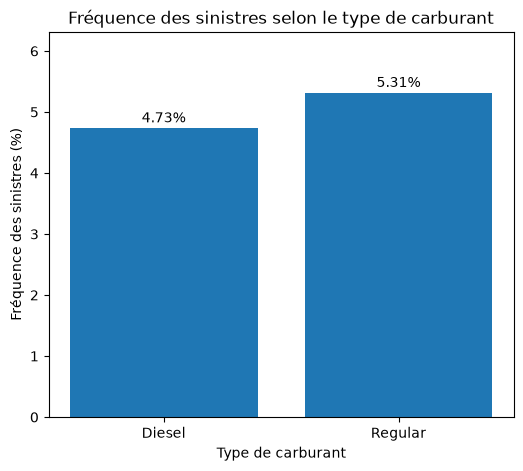

In [52]:
plt.figure(figsize=(6,5))

bars = plt.bar(
    gas_analysis.index.astype(str),
    gas_analysis["Fréquence des sinistres (%)"]
)

plt.title("Fréquence des sinistres selon le type de carburant")
plt.xlabel("Type de carburant")
plt.ylabel("Fréquence des sinistres (%)")

for bar, value in zip(bars, gas_analysis["Fréquence des sinistres (%)"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.1,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, gas_analysis["Fréquence des sinistres (%)"].max() + 1)

plt.show()

Analyse 8 — La région influence-t-elle le risque ?

In [53]:
freq["Region"].value_counts().sort_index()

Region
Alsace                           2200
Aquitaine                       31329
Auvergne                         5287
Basse-Normandie                 10893
Bourgogne                       10492
Bretagne                        42122
Centre                         160601
Champagne-Ardenne                3026
Corse                            4516
Franche-Comte                    1326
Haute-Normandie                  8784
Ile-de-France                   69791
Languedoc-Roussillon            35805
Limousin                         4567
Midi-Pyrenees                   17141
Nord-Pas-de-Calais              40275
Pays-de-la-Loire                38751
Picardie                         7994
Poitou-Charentes                19046
Provence-Alpes-Cotes-D'Azur     79315
Rhone-Alpes                     84752
Name: count, dtype: int64

In [54]:
risk_by_region = (
    freq.groupby("Region")["HasClaim"]
    .mean()
    .mul(100)
    .round(2)
)

In [55]:
region_analysis = pd.DataFrame({
    "Nombre de contrats": freq["Region"].value_counts().sort_index(),
    "Fréquence des sinistres (%)": risk_by_region
})

region_analysis = region_analysis.sort_values(
    by="Fréquence des sinistres (%)",
    ascending=False
)

region_analysis

,Nombre de contrats,Fréquence des sinistres (%)
Region,,
Bretagne,42122,6.11
Alsace,2200,5.64
Rhone-Alpes,84752,5.62
Basse-Normandie,10893,5.55
Centre,160601,5.48
Ile-de-France,69791,5.32
Limousin,4567,5.30
Picardie,7994,5.27
Pays-de-la-Loire,38751,4.93


Interprétation

Cette analyse compare la fréquence des sinistres selon les différentes régions du portefeuille d'assurance.

Les résultats montrent des écarts entre les régions. La Bretagne présente la fréquence observée la plus élevée (6,11 %), tandis que la Haute-Normandie présente la plus faible (3,23 %).

Certaines régions, comme Alsace (2 200 contrats) ou Franche-Comté (1 326 contrats), disposent d'un effectif relativement faible. Les résultats observés dans ces régions doivent donc être interprétés avec prudence, car la taille de l'échantillon peut influencer les pourcentages calculés.

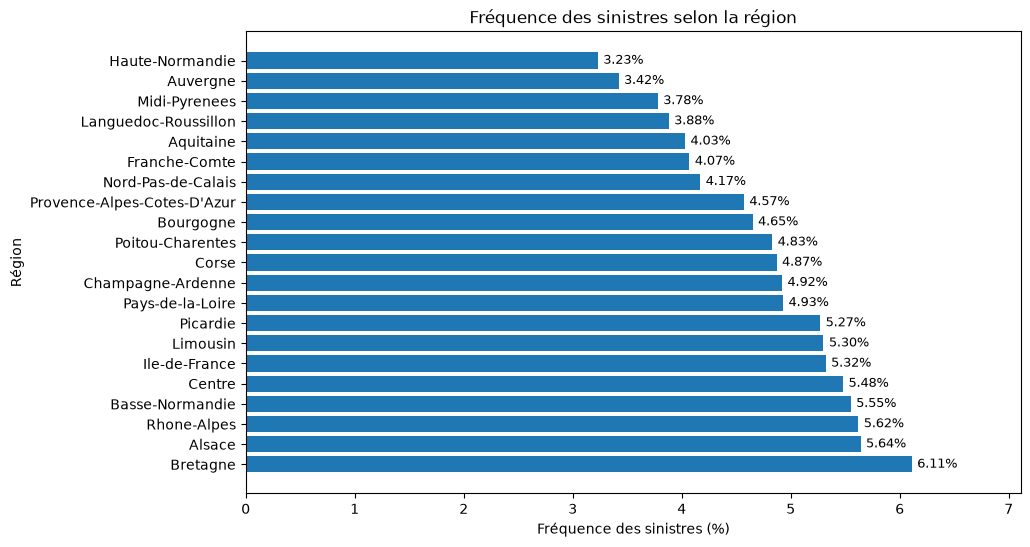

In [56]:
plt.figure(figsize=(10,6))

bars = plt.barh(
    region_analysis.index.astype(str),
    region_analysis["Fréquence des sinistres (%)"]
)

plt.title("Fréquence des sinistres selon la région")
plt.xlabel("Fréquence des sinistres (%)")
plt.ylabel("Région")

for bar, value in zip(bars, region_analysis["Fréquence des sinistres (%)"]):
    plt.text(
        value + 0.05,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}%",
        va="center",
        fontsize=9
    )

plt.xlim(0, region_analysis["Fréquence des sinistres (%)"].max() + 1)

plt.show()